# 📧 Project 2: Spam Detection
### SyntecXHub Virtual Internship — ML Pipeline Project

**Goal:** Build an end-to-end machine learning pipeline that classifies email/SMS messages as **Spam** or **Ham** (not spam), using classic NLP feature extraction (TF-IDF) combined with Naive Bayes and Logistic Regression classifiers.

**Pipeline overview:**
1. Load & inspect the labeled spam/ham dataset
2. Exploratory Data Analysis (EDA)
3. Text cleaning & preprocessing
4. Stratified train/test split
5. Build TF-IDF + model pipelines (Naive Bayes & Logistic Regression)
6. Evaluate with classification reports & confusion matrices
7. Serialize the best pipeline and run inference on new, unseen samples


## 1. Imports & Setup

Import all libraries needed for data handling, visualization, text preprocessing, modeling, and evaluation.

In [26]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re

# Model persistence
import joblib

# Scikit-learn: preprocessing, pipeline, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading & Inspection

Load `spam_ham_dataset.csv`, drop unnecessary index-like columns (e.g. `Unnamed: 0`), and inspect the dataset's shape, class balance, missing values, and a sample of rows.

> **Expected columns:** the dataset typically contains a text column (e.g. `text`) and a label column (e.g. `label` / `label_num`) indicating spam (1) or ham (0).

In [27]:
# Load the dataset
df = pd.read_csv("spam_ham_dataset.csv")

# Drop unnecessary columns if present (common artifact of exported CSVs)
cols_to_drop = [c for c in ["Unnamed: 0"] if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5171, 3)


,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [28]:
# Identify text and label columns (adjust names here if your CSV differs)
TEXT_COL = "text"
LABEL_COL = "label"  # expected values: 'spam' / 'ham' or 0 / 1

print("Columns:", list(df.columns))
print()
print("Class counts:")
print(df[LABEL_COL].value_counts())
print()
print("Missing values per column:")
print(df.isnull().sum())

Columns: ['label', 'text', 'label_num']

Class counts:
label
ham     3672
spam    1499
Name: count, dtype: int64

Missing values per column:
label        0
text         0
label_num    0
dtype: int64


In [29]:
# Quick look at a few sample messages from each class
print("Sample HAM message:\n")
print(df.loc[df[LABEL_COL].astype(str).str.lower().isin(["ham", "0"]), TEXT_COL].iloc[0][:300])

print("\n" + "-" * 60 + "\n")

print("Sample SPAM message:\n")
print(df.loc[df[LABEL_COL].astype(str).str.lower().isin(["spam", "1"]), TEXT_COL].iloc[0][:300])

Sample HAM message:

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed as

------------------------------------------------------------

Sample SPAM message:

Subject: photoshop , windows , office . cheap . main trending
abasements darer prudently fortuitous undergone
lighthearted charm orinoco taster
railroad affluent pornographic cuvier
irvin parkhouse blameworthy chlorophyll
robed diagrammatic fogarty clears bayda
inconveniencing managing represe


## 3. Exploratory Data Analysis (EDA)

Before modeling, let's understand the class balance and how message length differs between spam and ham.

### 3.1 Spam vs. Ham Distribution

C:\Users\Davit\AppData\Local\Temp\ipykernel_123684\3052449328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=LABEL_COL, palette="viridis")


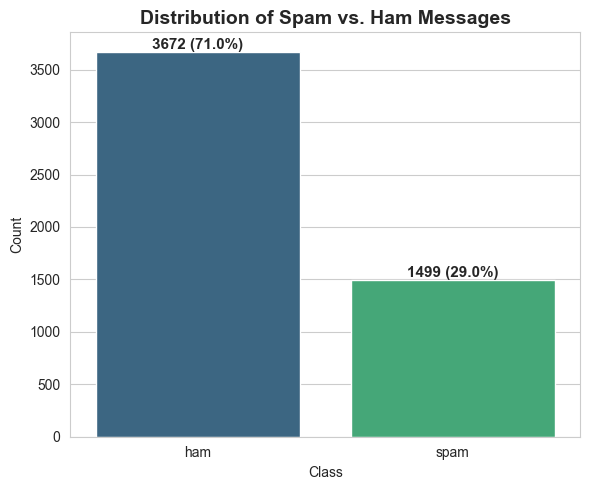

In [30]:
# Countplot of Spam vs Ham with percentage annotations
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x=LABEL_COL, palette="viridis")

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(
        f"{count} ({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.title("Distribution of Spam vs. Ham Messages", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.2 Message Length & Word Count by Class

In [31]:
# Derive character length and word count features for EDA purposes
df["char_length"] = df[TEXT_COL].astype(str).apply(len)
df["word_count"] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

df[["char_length", "word_count"]].describe()

,char_length,word_count
count,5171.000000,5171.000000
mean,1048.391994,227.783601
std,1528.513435,336.031616
min,11.000000,1.000000
25%,244.000000,51.000000
50%,540.000000,121.000000
75%,1237.000000,282.000000
max,32258.000000,8862.000000


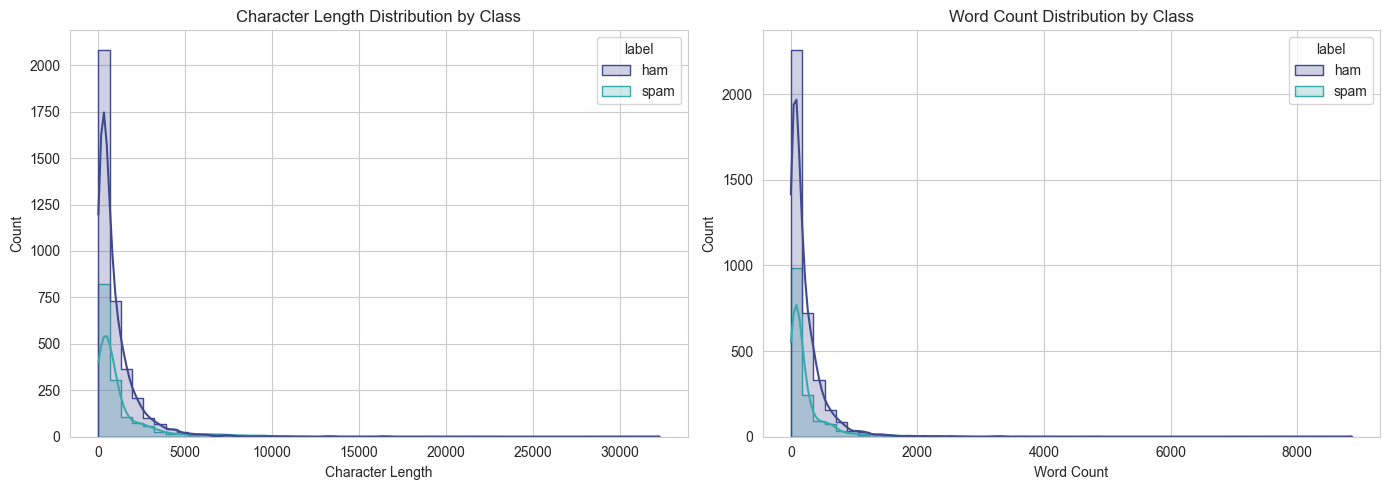

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="char_length", hue=LABEL_COL, bins=50,
             kde=True, element="step", ax=axes[0], palette="mako")
axes[0].set_title("Character Length Distribution by Class")
axes[0].set_xlabel("Character Length")

sns.histplot(data=df, x="word_count", hue=LABEL_COL, bins=50,
             kde=True, element="step", ax=axes[1], palette="mako")
axes[1].set_title("Word Count Distribution by Class")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.show()

## 4. Text Preprocessing

Define a `clean_text()` function that:
- Lowercases the text
- Removes email header prefixes such as `subject:`
- Strips non-alphabetic characters and punctuation
- Normalizes repeated/extra whitespace

In [33]:
def clean_text(text):
    """Clean raw email/SMS text for downstream TF-IDF vectorization."""
    text = str(text).lower()

    # Remove common email header prefixes (e.g. "subject:")
    text = re.sub(r"^subject\s*:\s*", "", text)
    text = re.sub(r"\bsubject\s*:\s*", " ", text)

    # Remove non-alphabetic characters (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Normalize extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply cleaning to the full dataset
df["clean_text"] = df[TEXT_COL].apply(clean_text)

# Preview before/after cleaning
df[[TEXT_COL, "clean_text"]].head()

,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,enron methanol meter this is a follow up to th...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",hpl nom for january see attached file hplnol x...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",neon retreat ho ho ho we re around to that mos...
3,"Subject: photoshop , windows , office . cheap ...",photoshop windows office cheap main trending a...
4,Subject: re : indian springs\r\nthis deal is t...,re indian springs this deal is to book the tec...


## 5. Train-Test Split

Split the cleaned data into **80% training** / **20% test** sets using **stratified sampling** on the labels, to preserve the original spam/ham class ratio in both splits.

In [34]:
X = df["clean_text"]
y = df[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print()
print("Training class distribution:")
print(y_train.value_counts(normalize=True))
print()
print("Test class distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 4136
Test set size:     1035

Training class distribution:
label
ham     0.710106
spam    0.289894
Name: proportion, dtype: float64

Test class distribution:
label
ham     0.710145
spam    0.289855
Name: proportion, dtype: float64


## 6. Feature Extraction & Pipeline Building

Build two independent `Pipeline` objects, each combining a shared `TfidfVectorizer` configuration with a different classifier:

- **Pipeline 1:** `TfidfVectorizer` → `MultinomialNB`
- **Pipeline 2:** `TfidfVectorizer` → `LogisticRegression`

Using `Pipeline` ensures vectorization and modeling are bundled together, which makes saving/loading and inference on new text straightforward and leak-free.

In [35]:
tfidf_params = dict(stop_words="english", max_features=5000)

# Pipeline 1: TF-IDF + Multinomial Naive Bayes
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("clf", MultinomialNB())
])

# Pipeline 2: TF-IDF + Logistic Regression
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

print(nb_pipeline)
print()
print(lr_pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('clf', MultinomialNB())])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


## 7. Model Evaluation

Train both pipelines on the training data, generate predictions on the held-out test set, and compare their performance using `classification_report` and confusion matrices.

### 7.1 Train Both Models

In [36]:
# Fit Naive Bayes pipeline
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)

# Fit Logistic Regression pipeline
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

print("Both models trained successfully.")

Both models trained successfully.


### 7.2 Classification Reports

In [37]:
print("=" * 60)
print("Naive Bayes — Classification Report")
print("=" * 60)
print(classification_report(y_test, nb_preds))
print(f"Accuracy: {accuracy_score(y_test, nb_preds):.4f}")

Naive Bayes — Classification Report
              precision    recall  f1-score   support

         ham       0.97      0.96      0.96       735
        spam       0.90      0.94      0.92       300

    accuracy                           0.95      1035
   macro avg       0.94      0.95      0.94      1035
weighted avg       0.95      0.95      0.95      1035

Accuracy: 0.9507


In [38]:
print("=" * 60)
print("Logistic Regression — Classification Report")
print("=" * 60)
print(classification_report(y_test, lr_preds))
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")

Logistic Regression — Classification Report
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       735
        spam       0.96      0.97      0.97       300

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035

Accuracy: 0.9797


### 7.3 Confusion Matrices

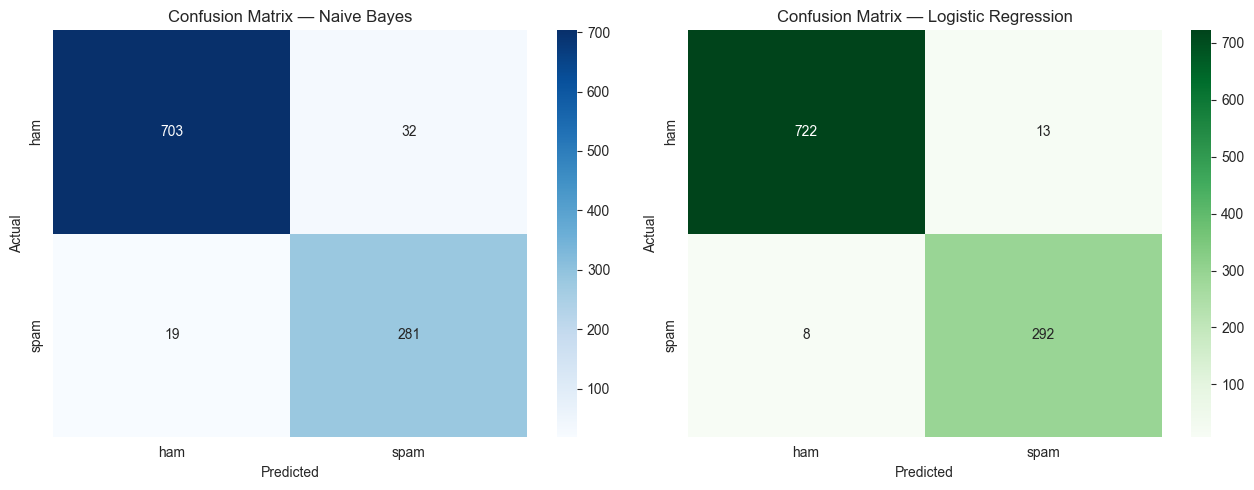

In [39]:
labels_order = sorted(y.unique())

cm_nb = confusion_matrix(y_test, nb_preds, labels=labels_order)
cm_lr = confusion_matrix(y_test, lr_preds, labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=axes[0])
axes[0].set_title("Confusion Matrix — Naive Bayes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels_order, yticklabels=labels_order, ax=axes[1])
axes[1].set_title("Confusion Matrix — Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Pipeline Serialization & Custom Inference

Save the **best performing pipeline** (Logistic Regression) to disk with `joblib`, then reload it and run predictions on **3 custom, unseen** email/SMS samples, printing the predicted label and the model's spam probability.

In [40]:
# Save the Logistic Regression pipeline (vectorizer + model bundled together)
joblib.dump(lr_pipeline, "spam_classifier_pipeline.joblib")
print("Pipeline saved to 'spam_classifier_pipeline.joblib'")

Pipeline saved to 'spam_classifier_pipeline.joblib'


In [41]:
# Reload the saved pipeline from disk
loaded_pipeline = joblib.load("spam_classifier_pipeline.joblib")
print("Pipeline reloaded successfully.")

Pipeline reloaded successfully.


In [42]:
# Three custom, unseen samples for inference
custom_samples = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!",
    "Hi John, can we move tomorrow's 10am meeting to 2pm? Let me know if that works.",
    "URGENT: Your account has been suspended. Verify your password immediately at this link."
]

# Clean the custom samples with the same preprocessing used in training
cleaned_samples = [clean_text(s) for s in custom_samples]

# Predict labels
predictions = loaded_pipeline.predict(cleaned_samples)

# Predict probabilities (assumes classes_ contains the spam label, e.g. 'spam' or 1)
probabilities = loaded_pipeline.predict_proba(cleaned_samples)
spam_class_index = list(loaded_pipeline.classes_).index(
    [c for c in loaded_pipeline.classes_ if str(c).lower() in ("spam", "1")][0]
)

for sample, pred, proba in zip(custom_samples, predictions, probabilities):
    spam_prob = proba[spam_class_index]
    print(f"Message: {sample[:70]}...")
    print(f"  → Predicted label: {pred}")
    print(f"  → Spam probability: {spam_prob:.2%}\n")

Message: Congratulations! You've won a $1000 Walmart gift card. Click here to c...
  → Predicted label: spam
  → Spam probability: 76.52%

Message: Hi John, can we move tomorrow's 10am meeting to 2pm? Let me know if th...
  → Predicted label: ham
  → Spam probability: 13.97%

Message: URGENT: Your account has been suspended. Verify your password immediat...
  → Predicted label: spam
  → Spam probability: 55.57%



## ✅ Summary

- Built and compared two text classification pipelines (**Naive Bayes** and **Logistic Regression**) on TF-IDF features.
- Evaluated both with classification reports and confusion matrices on a stratified 80/20 split.
- Serialized the Logistic Regression pipeline for reuse and validated it with predictions on new, unseen messages.

**Project 2: Spam Detection — SyntecXHub Virtual Internship** ✔️